<a href="https://colab.research.google.com/github/ArtemMint/Neural-Collaborative-Filtering/blob/main/Dyploma_CNN_RS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import keras
from keras.layers import *
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import schedules
from tensorflow.keras.layers import Embedding, Reshape, Dot
from keras.models import Sequential
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
BASE_PATH = "/content/gdrive/My Drive/Machine learning/Dyploma/"

In [ ]:
datasets_directory = os.path.join(
    BASE_PATH,
    "datasets",
    )
datasets_directory

'/content/gdrive/My Drive/Machine learning/Dyploma/datasets'

In [ ]:
for dirname, _, filenames in os.walk(datasets_directory):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/gdrive/My Drive/Machine learning/Dyploma/datasets/movies.csv
/content/gdrive/My Drive/Machine learning/Dyploma/datasets/movies_metadata.csv
/content/gdrive/My Drive/Machine learning/Dyploma/datasets/movies_ratings.csv


In [ ]:
movies_dataset = os.path.join(
    datasets_directory,
    "movies.csv",
    )

In [ ]:
movies_metadata_dataset = os.path.join(
    datasets_directory,
    "movies_metadata.csv",
)

In [ ]:
movies_ratings_dataset = os.path.join(
    datasets_directory,
    "movies_ratings.csv",
)

In [ ]:
movies_data = pd.read_csv(movies_dataset)
movies_data.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
movies_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [ ]:
movies_ratings = pd.read_csv(movies_ratings_dataset)
movies_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
movies_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [ ]:
movies_metadata =  pd.read_csv(movies_metadata_dataset)
movies_metadata.head(3)

/tmp/ipykernel_6447/3080910546.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata =  pd.read_csv(movies_metadata_dataset)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [ ]:
movies_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [ ]:
# movies_ratings['rank_latest'] = movies_ratings.groupby(['userId'])['timestamp'].rank(
#     method='first',
#     ascending=False,
#     )
# movies_ratings.head()

Build NN using Keras


In [ ]:
movies_ratings.userId = movies_ratings.userId.astype('category').cat.codes.values
movies_ratings.movieId = movies_ratings.movieId.astype('category').cat.codes.values

n_users = len(movies_ratings.userId.unique())
n_movies = len(movies_ratings.movieId.unique())
print('Унікальних користувачів: ', n_users)
print('Унікальних фільмів:', n_movies)

Унікальних користувачів:  610
Унікальних фільмів: 9724


In [ ]:
train_set, test_set = train_test_split(
    movies_ratings,
    test_size=0.25, )

In [ ]:
train_set.head()

,userId,movieId,rating,timestamp
82506,523,144,3.0,851609213
47069,306,1726,2.5,1186161833
21934,142,5767,4.0,1444880347
81147,513,984,2.5,1534114286
5011,31,823,4.0,856737338


In [ ]:
test_set.head()

,userId,movieId,rating,timestamp
9914,63,5360,3.5,1161559613
679,5,233,4.0,845555249
72289,465,1938,4.0,1439885067
41726,282,1182,4.0,901228155
53053,349,815,3.0,864940972


In [ ]:
class RS_Model():
    """ Модель для рекомендації фільмів користувачам """

    def __init__(
                self,
        ):
        pass

    def call():
        # model = keras.layers.ReLU()
        pass

In [ ]:
def neural_network_model(n_latent_factors_user, n_latent_factors_movie):
    movie_input = keras.layers.Input(shape=[1], name='Item')
    movie_embedding = keras.layers.Embedding(n_movies + 1,
                                             n_latent_factors_movie,
                                             name='Movie-Embedding')(movie_input)
    movie_vec = keras.layers.Flatten(name='FlattenMovies')(movie_embedding)
    movie_vec = keras.layers.Dropout(0.2)(movie_vec)

    user_input = keras.layers.Input(shape=[1], name='User')
    user_embedding = keras.layers.Embedding(n_users + 1,
                                            n_latent_factors_user,
                                            name='User-Embedding')(user_input)
    user_vec = keras.layers.Flatten(name='FlattenUsers')(user_embedding)
    user_vec = keras.layers.Dropout(0.2)(user_vec)

    concat = keras.layers.concatenate([movie_vec, user_vec], name='Concat')
    x = keras.layers.Dropout(0.2)(concat)

    x = keras.layers.Dense(100, name='FullyConnected-1', activation='relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    x = keras.layers.Dense(50, name='FullyConnected-2', activation='relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    x = keras.layers.Dense(20, name='FullyConnected-3', activation='relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    x = keras.layers.Dense(10, name='FullyConnected-4', activation='relu')(x)

    result = keras.layers.Dense(1, name='Activation')(x)

    model = keras.Model([user_input, movie_input], result)

    adam = Adam(learning_rate=0.001)
    model.compile(optimizer=adam, loss='mean_absolute_error')

    return model

In [ ]:
cnn_model = neural_network_model(10,13)

In [ ]:
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Item (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ User (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Movie-Embedding     │ (None, 1, 13)     │    126,425 │ Item[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ User-Embedding      │ (None, 1, 10)     │      6,110 │ User[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FlattenMovies       │ (None, 13)        │          0 │ Movie-Embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FlattenUsers        │ (None, 10)        │          0 │ User-Embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 13)        │          0 │ FlattenMovies[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 10)        │          0 │ FlattenUsers[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concat              │ (None, 23)        │          0 │ dropout_10[0][0], │
│ (Concatenate)       │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 23)        │          0 │ Concat[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FullyConnected-1    │ (None, 100)       │      2,400 │ dropout_12[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 100)       │          0 │ FullyConnected-1… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FullyConnected-2    │ (None, 50)        │      5,050 │ dropout_13[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 50)        │          0 │ FullyConnected-2… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FullyConnected-3    │ (None, 20)        │      1,020 │ dropout_14[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 20)        │          0 │ FullyConnected-3… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FullyConnected-4    │ (None, 10)        │        210 │ dropout_15[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 141,226 (551.66 KB)

 Trainable params: 141,226 (551.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_neural_network = cnn_model.fit(
    [train_set.userId, train_set.movieId],
    train_set.rating,
    validation_split = 0.1,
    epochs=30,
    verbose=1,
)

Epoch 1/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6084 - val_loss: 0.6827
Epoch 2/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6024 - val_loss: 0.6862
Epoch 3/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.5995 - val_loss: 0.6678
Epoch 4/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.5950 - val_loss: 0.6675
Epoch 5/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.5908 - val_loss: 0.6732
Epoch 6/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.5877 - val_loss: 0.6767
Epoch 7/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.5863 - val_loss: 0.6746
Epoch 8/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.5860 - val_loss: 0.6767
Epoch 9/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.5817 - val_loss: 0.6752
Epoch 10/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.5807 - val_loss: 0.6779
Epoch 11/30
2127/2127 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.5774 - val_loss: 0.6730
Epoch 12/30
2127/2127

In [ ]:
# from matplotlib import pyplot as plt
# plt.plot(history_neural_network.history['accuracy'])
# plt.plot(history_neural_network.history['val_accuracy'])
# plt.title('Точність моделі')
# plt.ylabel('Точність')
# plt.xlabel('Епохи')
# plt.legend(['Тренування', 'Валідація'], loc='upper left')
# plt.show()

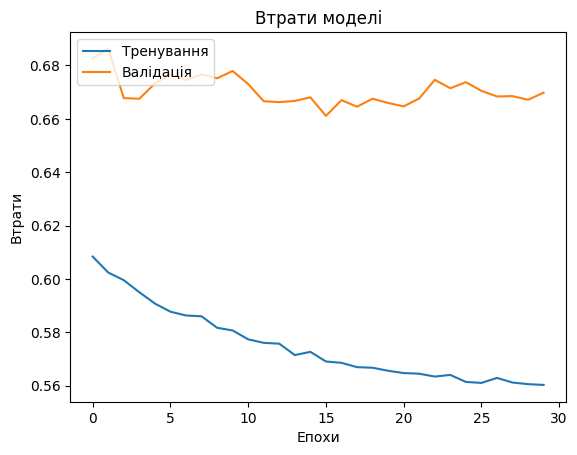

In [ ]:
from matplotlib import pyplot as plt
plt.plot(history_neural_network.history['loss'])
plt.plot(history_neural_network.history['val_loss'])
plt.title('Втрати моделі')
plt.ylabel('Втрати')
plt.xlabel('Епохи')
plt.legend(['Тренування', 'Валідація'], loc='upper left')
plt.show()

In [ ]:
y_hat = pd.Series(np.round(
    cnn_model.predict(
        [test_set.userId, test_set.movieId]),0).reshape(-1),
        name='predicted')
y_true = test_set.rating

788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [ ]:
q = pd.concat(
    [test_set.drop('timestamp', axis=1), y_hat],
    axis=1,
    join='inner',
    )
q.sort_values(by=['rating','predicted'], ascending=False)

,userId,movieId,rating,predicted
5114,32,978,5.0,5.0
725,5,314,5.0,5.0
18003,112,697,5.0,5.0
24859,174,6150,5.0,5.0
16442,104,4103,5.0,5.0
...,...,...,...,...
1130,9,1938,0.5,3.0
22432,152,396,0.5,3.0
23699,160,6208,0.5,2.0
22470,152,1756,0.5,2.0


In [ ]:
model_accuracy = mean_absolute_error(y_true, y_hat)
model_accuracy

0.6808679439882581